# Animating footprint time series

`fluxfootprints.footprint_animation` turns the time-resolved footprint
rasters produced by any model in this package into a **video or animated GIF**,
one frame per time step, with the timestamp drawn on each frame.

This notebook covers:

1. building a footprint time series from half-hourly tower data,
2. animating it at **hourly**, **daily**, and **monthly** time steps,
3. drawing the footprint over a **georeferenced basemap**,
4. exporting **MP4** as well as GIF, and
5. the styling options (color scaling, masking, source-area contours).

## Requirements

GIF output works with a bare install. Basemaps and MP4/WebM need the optional
extra, which pulls in [contextily](https://contextily.readthedocs.io) (map
tiles) and [imageio-ffmpeg](https://github.com/imageio/imageio-ffmpeg) (a
bundled `ffmpeg` binary):

```bash
pip install "fluxfootprints[animation]"
```

An `ffmpeg` already on your `PATH` is used in preference to the bundled copy.

## Setup

In [1]:
import base64
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML

sys.path.insert(0, os.path.abspath("../../src"))  # adjust path as needed

from fluxfootprints import (
    FootprintAnimator,
    animate_footprint,
    build_climatology,
    summarize_periods,
)
from fluxfootprints.footprint_animation import ensure_ffmpeg

OUT = Path("output")
OUT.mkdir(exist_ok=True)


def show(path, width=460):
    """Embed an animation inline, base64-encoded.

    ``IPython.display.Image`` renders GIFs in Jupyter but the ``image/gif``
    output is dropped when Sphinx builds these pages, so the animations below
    are embedded as HTML instead -- that renders everywhere.
    """
    path = Path(path)
    data = base64.b64encode(path.read_bytes()).decode("ascii")
    if path.suffix == ".mp4":
        return HTML(
            f'<video controls loop width="{width}" '
            f'src="data:video/mp4;base64,{data}"></video>'
        )
    mime = "image/gif" if path.suffix == ".gif" else "image/png"
    return HTML(f'<img src="data:{mime};base64,{data}" width="{width}">')

# Example site location (used for georeferencing further down):
# irrigated pasture in Cache Valley, Utah.
STATION_LAT, STATION_LON = 41.66, -111.89

## 1. Half-hourly tower data

The animator needs a footprint time series, which in turn needs half-hourly
micrometeorology. For a real site you would read it with
`load_amf_df()`; here we synthesise six months of
plausible-looking data so the notebook runs anywhere.

The wind direction drifts on a multi-day cycle and the turbulence follows a
diurnal cycle, so the footprint both rotates and grows/shrinks over time --
which is what makes the animation worth watching.

In [2]:
rng = np.random.default_rng(42)

times = pd.date_range("2023-04-01", "2023-09-30 23:30", freq="30min")
n = len(times)

hour = (times.hour + times.minute / 60).to_numpy()
doy = times.dayofyear.to_numpy()

# Daytime fraction: 0 at night, 1 at solar noon.
day = np.clip(np.sin(np.pi * (hour - 6) / 12), 0, None)

met = pd.DataFrame(
    {
        # prevailing direction swings back and forth over ~25-day cycles
        "wind_dir": (200 + 70 * np.sin(2 * np.pi * doy / 25) + rng.normal(0, 12, n)) % 360,
        "umean": 2.0 + 2.5 * day + rng.normal(0, 0.3, n),
        "ustar": (0.12 + 0.35 * day + rng.normal(0, 0.04, n)).clip(0.05, None),
        # unstable by day, stable at night
        "ol": np.where(day > 0.1, -50.0 / (day + 0.05), 120.0),
        "sigmav": (0.30 + 0.60 * day + rng.normal(0, 0.05, n)).clip(0.10, None),
        "zm": 2.0,     # measurement height (m)
        "z0": 0.05,    # roughness length (m)
        "h": 500 + 1200 * day,   # boundary-layer height (m)
        "LE": (20 + 220 * day + rng.normal(0, 10, n)).clip(0, None),  # W m-2
    },
    index=times,
)
met.index.name = "datetime_start"
met.head()

,wind_dir,umean,ustar,ol,sigmav,zm,z0,h,LE
datetime_start,,,,,,,,,
2023-04-01 00:00:00,149.720678,1.902912,0.105943,120.0,0.325440,2.0,0.05,500.0,32.588329
2023-04-01 00:30:00,133.584264,2.127531,0.097906,120.0,0.351048,2.0,0.05,500.0,10.238564
2023-04-01 01:00:00,155.069487,2.492085,0.169734,120.0,0.255680,2.0,0.05,500.0,27.798096
2023-04-01 01:30:00,157.350850,2.505937,0.088282,120.0,0.309927,2.0,0.05,500.0,18.950612
2023-04-01 02:00:00,122.651651,1.591055,0.103610,120.0,0.292963,2.0,0.05,500.0,21.253645


## 2. Build the footprint time series

Any model registered with `build_climatology()` works. The
animator reads the per-timestep rasters through `get_footprint_timeseries()`,
so it is model-agnostic -- swap `model_type` for `"kormann-meixner"`, `"ls"`,
or `"wang"` and everything below is unchanged.

In [3]:
model = build_climatology(
    met,
    model_type="ffp",
    ustar="ustar",
    ol="ol",
    umean="umean",
    sigmav="sigmav",
    wind_dir="wind_dir",
    zm="zm",
    z0="z0",
    h="h",
    dx=15.0,
    dy=15.0,
    domain=(-400.0, 400.0, -400.0, 400.0),
    verbosity=0,
)

f_2d = model.get_footprint_timeseries()
print("footprint time series:", dict(f_2d.sizes))
print("time range:", str(f_2d.time.values[0])[:16], "->", str(f_2d.time.values[-1])[:16])

footprint time series: {'time': 7426, 'x': 55, 'y': 55}
time range: 2023-04-01T00:00 -> 2023-09-30T23:30


## 3. Hourly animation

`freq="hourly"` averages the half-hourly rasters into hourly frames. The other
accepted values are `"daily"`, `"monthly"`, `"native"`/`None` (no resampling),
and any pandas offset alias such as `"3h"`.

A few options that make footprints legible:

- `mask_quantile` makes the near-zero background transparent, so only the
  meaningful part of the footprint is painted;
- `contour_fractions=(0.5, 0.8)` outlines the 50 % and 80 % source areas;
- `time_slice` trims the series -- here to a single day, to keep the GIF small.

The timestamp format defaults to the time step (`%Y-%m-%d %H:%M` for hourly)
and can be overridden with `timestamp_format`.


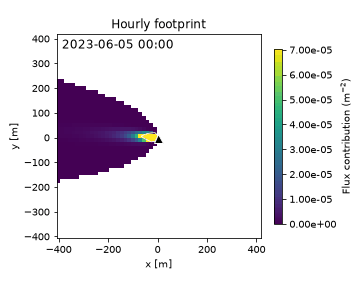

In [4]:
hourly_gif = animate_footprint(
    model,
    OUT / "ffp_hourly.gif",
    freq="hourly",
    time_slice=("2023-06-05", "2023-06-05 23:59"),
    mask_quantile=0.55,
    contour_fractions=(0.5, 0.8),
    title="Hourly footprint",
    fps=5,
    dpi=72,
    figsize=(5.0, 4.0),
)

show(hourly_gif)

## 4. Daily and monthly steps

Two routes give you daily and monthly frames:

- pass `freq="daily"` / `freq="monthly"` and let the animator resample, or
- animate the summaries from `summarize_periods()` with
  `FootprintAnimator.from_summary()`, which also gives you
  the **ET-weighted** layers.

`from_summary` takes the timestamp format from the layer, so monthly frames are
labelled `June 2023` rather than `2023-06-01`.


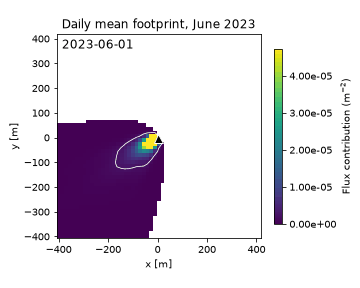

In [5]:
summaries = summarize_periods(model, met, et_source="LE", is_le=True)

daily_gif = FootprintAnimator.from_summary(
    summaries,
    layer="daily_mean",
    time_slice=("2023-06-01", "2023-06-30"),
    mask_quantile=0.55,
    contour_fractions=(0.8,),
    title="Daily mean footprint, June 2023",
    fps=8,
    dpi=72,
    figsize=(5.0, 4.0),
).save(OUT / "ffp_daily.gif")

show(daily_gif)

Monthly frames from the same summaries. `layer="monthly_etw"` would use the
evapotranspiration-weighted footprint instead of the plain mean -- the layer
that answers *"where did the water actually come from this month?"*


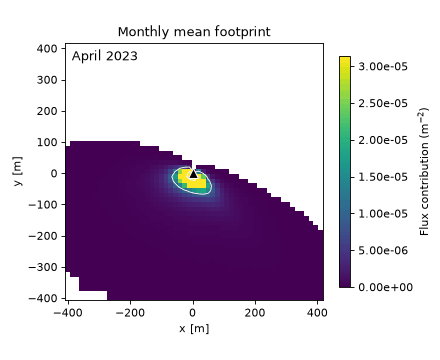

In [6]:
monthly_gif = FootprintAnimator.from_summary(
    summaries,
    layer="monthly_mean",
    mask_quantile=0.5,
    contour_fractions=(0.5, 0.8),
    title="Monthly mean footprint",
    fps=1,
    dpi=80,
    figsize=(5.5, 4.5),
).save(OUT / "ffp_monthly.gif")

show(monthly_gif)

## 5. Georeferenced basemap

Give the animator `station_lat` / `station_lon` and the grid stops being
"metres from the tower": it is placed in the local UTM zone (or whatever
projected CRS you pass as `crs_out`), using the same convention as
`export_rasters_geotiff()`.

With `basemap=True`, contextily fetches map tiles for that window once and
draws them under every frame. Because the footprint is drawn semi-transparently
(`alpha`, default 0.75 with a basemap) and the background is masked out, you can
see which fields the flux is coming from.

> Tile fetching needs network access. If it fails, the animation is still
> written -- you just get a warning and no basemap.


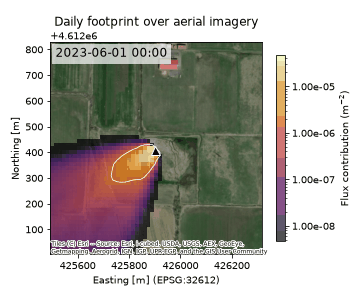

In [7]:
import contextily as cx

basemap_gif = animate_footprint(
    summaries.f_daily_mean,
    OUT / "ffp_daily_basemap.gif",
    time_slice=("2023-06-01", "2023-06-10"),
    station_lat=STATION_LAT,
    station_lon=STATION_LON,
    basemap=True,
    basemap_source=cx.providers.Esri.WorldImagery,
    norm="log",
    cmap="inferno",
    mask_quantile=0.6,
    alpha=0.7,
    contour_fractions=(0.8,),
    title="Daily footprint over aerial imagery",
    fps=3,
    dpi=72,
    figsize=(5.0, 4.2),
)

show(basemap_gif)

The example above asks for Esri aerial imagery; leaving `basemap_source` out
uses contextily's default (OpenStreetMap), and any other
[contextily provider](https://contextily.readthedocs.io/en/latest/providers_deepdive.html)
works too. `basemap_zoom` pins the tile zoom level when the automatic choice is
too coarse or too slow:

```python
animate_footprint(
    summaries.f_daily_mean,
    "out.gif",
    station_lat=STATION_LAT,
    station_lon=STATION_LON,
    basemap=True,
    basemap_source=cx.providers.OpenStreetMap.Mapnik,
    basemap_zoom=16,
)
```

Note the `log` color scale in the example: footprint densities span many orders
of magnitude, so `norm="log"` with `log_decades` (4 by default) shows the tail
of the footprint that a linear scale flattens to a single color.

## 6. MP4 output

The file suffix picks the writer: `.gif` (Pillow), `.mp4` / `.mov` / `.m4v` /
`.webm` (ffmpeg), and `.html` (a self-contained player).
`ensure_ffmpeg()` reports which binary
will be used -- an `ffmpeg` on `PATH` if there is one, otherwise the copy
bundled with `imageio-ffmpeg`.

In [8]:
ffmpeg_exe = ensure_ffmpeg()
print("ffmpeg:", Path(ffmpeg_exe).name if ffmpeg_exe else "not found")

mp4 = animate_footprint(
    model,
    OUT / "ffp_hourly.mp4",
    freq="hourly",
    time_slice=("2023-06-05", "2023-06-07"),
    mask_quantile=0.55,
    title="Hourly footprint",
    fps=6,
    dpi=80,
    figsize=(5.5, 4.5),
)
print(f"{mp4} ({mp4.stat().st_size / 1024:.0f} KB)")

show(mp4)

ffmpeg: ffmpeg-win-x86_64-v7.1.exe


output\ffp_hourly.mp4 (59 KB)


## 7. Styling, frames, and embedding

`color_scale` decides whether frames are comparable to each other:

- `"global"` (default) fixes the color limits across the whole animation, so a
  fading footprint really looks like it is fading;
- `"per_frame"` rescales every frame to its own maximum, which maximises
  contrast but hides changes in magnitude.

`annotation_fn` adds a second line of text under the timestamp, and
`frames_dir` writes every frame out as a numbered PNG next to the animation --
handy for pulling a single date into a paper figure.

6 frames written, e.g. frame_0_20230401T0000.png



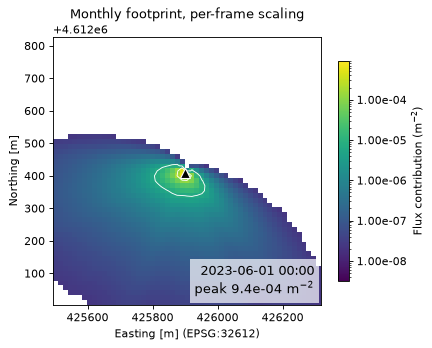

In [9]:
anim = FootprintAnimator(
    summaries.f_monthly_mean,
    station_lat=STATION_LAT,
    station_lon=STATION_LON,
    color_scale="per_frame",
    norm="log",
    mask_quantile=0.5,
    contour_fractions=(0.5, 0.8),
    annotation_fn=lambda ts, arr: f"peak {np.nanmax(arr):.1e} m$^{{-2}}$",
    timestamp_loc="lower right",
    title="Monthly footprint, per-frame scaling",
    fps=1,
    dpi=80,
    figsize=(5.5, 4.5),
)
anim.save(OUT / "ffp_monthly_styled.gif", frames_dir=OUT / "frames")

frames = sorted((OUT / "frames").glob("*.png"))
print(f"{len(frames)} frames written, e.g. {frames[0].name}")

show(frames[2])

To embed an animation in a notebook without writing a file at all, use
`build()` and matplotlib's own HTML player:

```python
fig, animation = anim.build()
HTML(animation.to_jshtml())
```

## Parameter cheat-sheet

| Parameter | What it does |
| --- | --- |
| `freq` | `"hourly"`, `"daily"`, `"monthly"`, `"native"`, or a pandas alias |
| `reducer` | how frames are aggregated when resampling (`"mean"`, `"sum"`, ...) |
| `normalize_each_frame` | rescale each frame to sum to 1 (compare shape, not magnitude) |
| `time_slice` | `(start, stop)` subset of the time axis |
| `station_lat` / `station_lon` | georeference the grid; required for basemaps |
| `crs_out` | target projected CRS (`"auto"` = local UTM zone) |
| `basemap`, `basemap_source`, `basemap_zoom` | contextily tile layer |
| `norm`, `cmap`, `vmin`, `vmax`, `percentiles` | color scaling |
| `color_scale` | `"global"` (comparable frames) or `"per_frame"` (max contrast) |
| `mask_below`, `mask_quantile`, `alpha` | hide/soften the near-zero background |
| `contour_fractions` | source-area contours drawn per frame |
| `title`, `timestamp_format`, `timestamp_loc`, `annotation_fn` | text |
| `fps`, `dpi`, `figsize` | output size and speed |

See the [API reference](../fluxfootprints.rst) for the full signature.